<a href="https://colab.research.google.com/github/ojaspaul123/DL-journey/blob/main/CNN/Pooling_Demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**The Problem with Convolution**     
Convolutional layers detect features (edges, textures, patterns) by sliding filters across an image. But this creates a problem: the output is sensitive to exact pixel location.   

If a feature shifts even slightly in the input image (the cat moves a few pixels to the left), the feature map produced by convolution changes too. The network ends up treating "cat shifted left" as somewhat different from "cat in original position," even though it's the same object. This is wasteful — a good image classifier shouldn't care exactly where a feature appears, just that it appears.     

There's also a practical issue: deep CNNs stack many convolutional layers, and each one preserves the spatial dimensions of the input (or reduces them only slightly). Without some way to shrink the feature maps, the number of parameters and computations explodes as you go deeper.

**What Is Translation Variance**     

Translation variance means the output of an operation changes when the input is shifted (translated) in space.

* A translation-invariant system gives the same output regardless of where the feature is located.
* A translation-variant system gives a different output depending on the position of the feature.

Plain convolution is translation-equivariant, not invariant: if you shift the input, the feature map shifts by a corresponding amount — the response moves but doesn't disappear or change shape. This is actually useful, but on its own, the network's final decision (e.g., "is this a cat?") would still depend too heavily on exact pixel positions unless something forces a degree of positional tolerance. Pooling is the mechanism that introduces that tolerance.

**What Is Pooling**      

Pooling is a downsampling operation applied after convolution. It slides a small window (e.g., 2×2) across the feature map and reduces each window to a single value, summarizing the information in that region.
Effects of pooling:

1. Reduces spatial dimensions (height and width) of feature maps, cutting computation and memory for later layers.
2. Adds local translation tolerance — since a window summarizes a small region into one number, a small shift in feature position within that window often produces the same pooled output.
3. Controls overfitting to some extent, by reducing the number of parameters in subsequent layers.

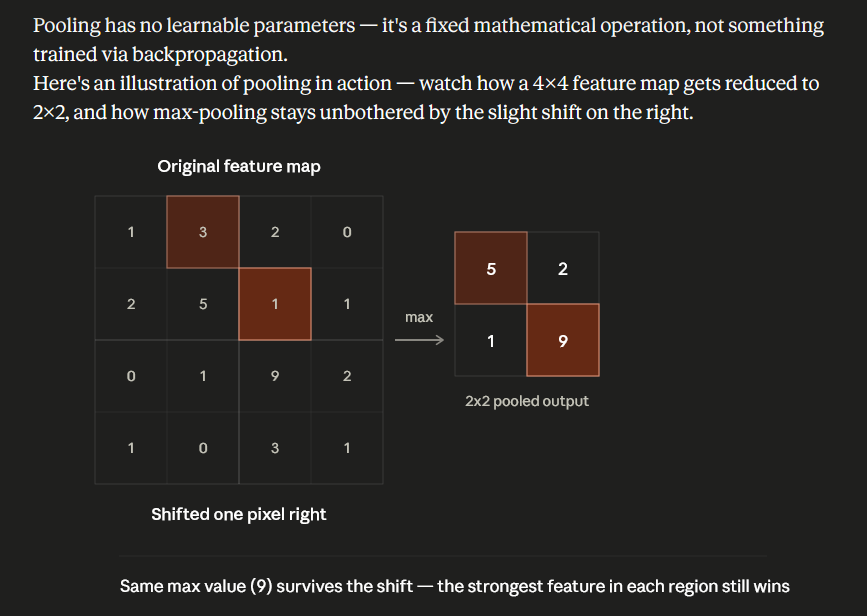

**POOLING-DEMO**

In [1]:
import tensorflow
from tensorflow import keras
from keras.layers import Dense,Conv2D,Flatten,MaxPooling2D
from keras import Sequential
from keras.datasets import mnist

In [2]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [3]:
model = Sequential()

model.add(Conv2D(32,kernel_size=(3,3),padding='valid', activation='relu', input_shape=(28,28,1)))
model.add(MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid'))
model.add(Conv2D(32,kernel_size=(3,3),padding='valid', activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid'))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dense(10,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [4]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       102,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 113,386 (442.91 KB)

 Trainable params: 113,386 (442.91 KB)

 Non-trainable params: 0 (0.00 B)

**Types of Pooling**
1. Max Pooling

Takes the maximum value from each window. Most common type — it picks out the strongest activation, which usually corresponds to the most prominent feature (an edge, a bright spot, a strong match to a filter).     
2. Average Pooling

Takes the average of all values in each window. Smooths the feature map rather than picking an extreme; preserves more background/context information but can dilute strong signals.    
3. Global Average Pooling (GAP)

Reduces an entire feature map (regardless of size) down to a single value by averaging all of it. Often used right before a final classification layer, replacing flatten + dense layers and drastically cutting parameters.    
4. Global Max Pooling

Same idea as GAP, but takes the single maximum value across the entire feature map instead of the average.    
5. L2-Norm Pooling (less common)

Takes the square root of the sum of squares of values in the window — a smoother alternative to max pooling, occasionally used in specific architectures.

**Advantages of Pooling**

* Reduces computation and memory — smaller feature maps mean fewer parameters in subsequent layers.
* Provides local translation tolerance — small shifts in feature position often don't change the pooled output.
* Controls overfitting — fewer parameters downstream means less capacity to memorize noise.
* Increases the effective receptive field — deeper layers "see" a larger region of the original image without needing larger filters.
* No parameters to learn — pooling is computationally cheap, with nothing to train.

**Disadvantages of Pooling**

* Loses spatial information — by collapsing a region to one value, exact location and fine-grained spatial detail are discarded. This can hurt tasks like segmentation or pose estimation where precise location matters.
* Can discard useful information — max pooling throws away everything except the single highest value in a window, which may lose context (e.g., texture or secondary features).
* Aggressive downsampling can be too lossy — pooling too many times across a deep network can shrink feature maps so much that important detail is irrecoverably lost.
* Not learnable — since it's fixed, the network can't adapt how it pools, unlike convolution where filters are learned. Some modern architectures (e.g., certain ResNet variants, or networks using strided convolutions instead) skip pooling for this reason, letting the network learn its own downsampling.
* Limited invariance, not full invariance — pooling gives only local tolerance to translation, within the size of the pooling window. Large shifts across the image still change the output significantly.